In [1]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random, importlib
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.config import get_cfg

# import our functions 
os.chdir("../../util/preprocessing")
import tumor_dataset

importlib.reload(tumor_dataset)
from tumor_dataset import Dataset

In [2]:
from detectron2.data.datasets import register_coco_instances
d = Dataset(data_path="../../data/raw_data/useable_data")
d.convert_binary_to_coco()
d.register_instances(rgb=True)

Init Dataset
Created 231 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/masks
Created 64 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/masks
Created 53 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/masks
Created 231 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/train/masks
Created 64 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/val/masks
Created 53 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/depth/test/masks
Created 231 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgd/train/masks
Created 64 annotations for images in folder: /projects/PUCHALLA/LLP2024/tumor-segmentation/data

In [3]:
train_metadata = MetadataCatalog.get("my_dataset_train")
train_dataset_dicts = DatasetCatalog.get("my_dataset_train")

val_metadata = MetadataCatalog.get("my_dataset_val")
val_dataset_dicts = DatasetCatalog.get("my_dataset_val")

test_metadata = MetadataCatalog.get("my_dataset_test")
test_dataset_dicts = DatasetCatalog.get("my_dataset_test")

[08/08 15:04:46 d2.data.datasets.coco]: Loaded 231 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/train/images/train.json
[08/08 15:04:46 d2.data.datasets.coco]: Loaded 64 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val.json
[08/08 15:04:46 d2.data.datasets.coco]: Loaded 53 images in COCO format from /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/test/images/test.json


Image file: /projects/PUCHALLA/LLP2024/tumor-segmentation/data/processed_data/rgb/val/images/val_22.jpg
Mask file: ../../data/processed_data/val/masks/Tumor/val_22.png
Failed to load mask: ../../data/processed_data/val/masks/Tumor/val_22.png


[ WARN:0@2.319] global loadsave.cpp:241 findDecoder imread_('../../data/processed_data/val/masks/Tumor/val_22.png'): can't open/read file: check file path/integrity


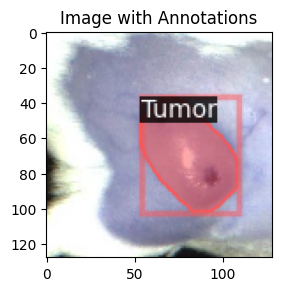

In [4]:
mask_folder = "../../data/processed_data/val/masks/Tumor"  # Update with your binary mask folder path

for d in random.sample(val_dataset_dicts, 1):
    # Load the image
    img = cv2.imread(d["file_name"])

    print(f"Image file: {d['file_name']}")
    
    # Check if the image was successfully loaded
    if img is None:
        print(f"Failed to load image: {d['file_name']}")
        continue

    # Visualize the image with annotations
    visualizer = Visualizer(img[:, :, ::-1], metadata=val_metadata, scale=0.5)
    vis = visualizer.draw_dataset_dict(d)

    # Display the annotated image
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    plt.imshow(vis.get_image()[:, :, ::-1])
    plt.title("Image with Annotations")

    # Load the corresponding binary mask
    image_base_name = os.path.basename(d["file_name"]).split(".")[0]  # Get base name of the image
    mask_path = os.path.join(mask_folder, f"{image_base_name}.png")  # Assuming masks have .jpg extension

    print(f"Mask file: {mask_path}")
    
    # Load the binary mask
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Check if the mask was successfully loaded
    if mask_img is None:
        print(f"Failed to load mask: {mask_path}")
        continue

    # Display the binary mask
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    plt.imshow(mask_img, cmap="gray")
    plt.title("Binary Mask")

    plt.show()  # Display the images side by side

now essentially what we want to do here is create a sub class of the default trainer so we can implement image augmentations.
These augmentations were defined by the medsam2 paper, seemed good enough to use here 

In [5]:
os.chdir("../../src/Detectron2")
from TrainerClass import Trainer

In [4]:
iterations = 5000
model_name = "testing-new-LR-4-5000"

cfg = get_cfg()
cfg.MODELNAME = model_name
cfg.OUTPUT_DIR = f"../../../../models/rgb-testing/{cfg.MODELNAME}"
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train", "my_dataset_val")
cfg.DATASETS.TEST = ("my_dataset_test",)
cfg.DATALOADER.NUM_WORKERS = 1
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False # this is for our "no tumor" examples 
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.MAX_ITER = iterations   
cfg.SOLVER.STEPS = []        
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  

# # ROI Head Configuration (Accuracy-focused)
# cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512
# cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION = 0.5  # More positive samples
# cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.3   # Lower detection threshold
# cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3     # Lower NMS for medical

cfg.SOLVER.BASE_LR = 0.0005   # Conservative LR for medical data
cfg.SOLVER.STEPS = [3000, 4000]  # Later LR reduction
cfg.SOLVER.GAMMA = 0.5        # Gentler LR decay
cfg.SOLVER.WARMUP_ITERS = 800
cfg.SOLVER.WARMUP_FACTOR = 0.1

In [5]:
cfg.MODEL.WEIGHTS = os.path.join("/projects/PUCHALLA/LLP2024/tumor-segmentation/models/rgb-testing/AP-bug-fix-2-5000/model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

[08/08 15:04:58 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /projects/PUCHALLA/LLP2024/tumor-segmentation/models/rgb-testing/AP-bug-fix-2-5000/model_final.pth ...


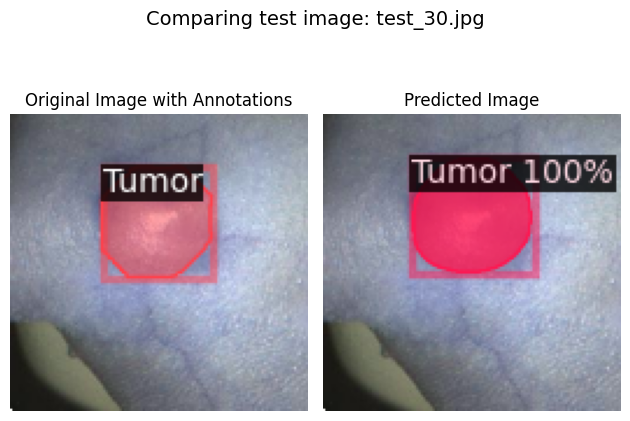

In [14]:
# Function to display the original image with annotations and the predicted image
import copy

def display_original_and_prediction_with_annotations(val_dataset_dicts, predictor, val_metadata):
    for d in random.sample(val_dataset_dicts, 1):
        im = cv2.imread(d["file_name"])
        outputs = predictor(im)

        # Create custom metadata with red colors
        red_metadata = copy.deepcopy(val_metadata)
        num_classes = len(red_metadata.thing_classes)
        red_metadata.thing_colors = [(0, 0, 255)] * num_classes 
        
        # Create a visualizer for ground truth (original colors)
        v_gt = Visualizer(im[:, :, ::-1],
                          metadata=red_metadata,
                          scale=0.5,
                          instance_mode=ColorMode.SEGMENTATION
        )
        out_gt = v_gt.draw_dataset_dict(d)
        

        
        # Create a visualizer for predictions with red metadata
        v_pred = Visualizer(im[:, :, ::-1],
                            metadata=red_metadata,
                            scale=0.5,
                            instance_mode=ColorMode.SEGMENTATION
        )
        
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))

        image_name = os.path.basename(d["file_name"])
        
        # Rest of your plotting code...
        fig, ax = plt.subplots(1, 2,)
        fig.suptitle("Comparing test image: test_30.jpg", fontsize=14, y=0.95)
        
        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Original Image with Annotations')
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Predicted Image')
        
        for a in ax:
            a.axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.92]) 
        plt.show()

# Example usage
display_original_and_prediction_with_annotations(test_dataset_dicts, predictor, test_metadata)


In [11]:
def save_all_images(val_dataset_dicts, predictor, val_metadata, output_dir):
    
    #create image path if it doesnt exist 
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for i, d in enumerate(val_dataset_dicts):

        im = cv2.imread(d["file_name"])
        outputs = predictor(im)
        
        v_gt = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5)
        out_gt = v_gt.draw_dataset_dict(d)
        
        v_pred = Visualizer(im[:, :, ::-1], metadata=val_metadata, scale=0.5, instance_mode=ColorMode.IMAGE_BW)
        out_pred = v_pred.draw_instance_predictions(outputs["instances"].to("cpu"))
        
        fig, ax = plt.subplots(1, 2, figsize=(30, 30))

        ax[0].imshow(out_gt.get_image()[:, :, ::-1])
        ax[0].set_title('Image with Original Annotations', fontsize=24)
        ax[0].axis('off')
        
        # Display the predicted image
        ax[1].imshow(out_pred.get_image()[:, :, ::-1])
        ax[1].set_title('Images with Annotations produced by the model', fontsize=24)
        ax[1].axis('off')
        
        fig.savefig(os.path.join(output_dir, f"image_{i}.png"), bbox_inches="tight")
        plt.close(fig) 

In [16]:
save_all_images(test_dataset_dicts, predictor, test_metadata, './detectron2/images_rgb')